In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from keras import models, layers, optimizers
import matplotlib.image as mpimg
import math

import os

In [32]:
BASE_DIR = '../input/intel-image-classification'
TRAIN_DIR = os.path.join(BASE_DIR, 'seg_train/seg_train')
TEST_DIR = os.path.join(BASE_DIR, 'seg_test/seg_test')
BATCH_SIZE = 20
EPOCHS = 30

#ImageDataGenerator for training data
TRAIN_DATAGEN = ImageDataGenerator(
                rescale = 1.0/255,
                validation_split = 0.2
                )

#ImageDataGenerator for testing data
TEST_DATAGEN = ImageDataGenerator(
                rescale = 1.0/255
                )

In [33]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/intel-image-classification


In [36]:
import os

# Check what's in your input directory
print("Contents of /kaggle/input:", os.listdir("/kaggle/input"))

# If the dataset appears with a different name, adjust this:
dataset_name = "intel-image-classification"  # Change this if different in the output above
BASE_DIR = f"/kaggle/input/{dataset_name}"
print("\nContents of dataset:", os.listdir(BASE_DIR))

Contents of /kaggle/input: ['intel-image-classification']

Contents of dataset: ['seg_train', 'seg_pred', 'seg_test']


In [37]:
# After verifying the correct paths above, use:
TRAIN_DIR = f"{BASE_DIR}/seg_train/seg_train"  # or whatever the actual structure shows
TEST_DIR = f"{BASE_DIR}/seg_test/seg_test"

# Double-check
if os.path.exists(TRAIN_DIR):
    print(f"Found {len(os.listdir(TRAIN_DIR))} training classes")
else:
    print("Training directory not found. Actual structure:")
    for root, dirs, files in os.walk(BASE_DIR):
        print(root)

Found 6 training classes


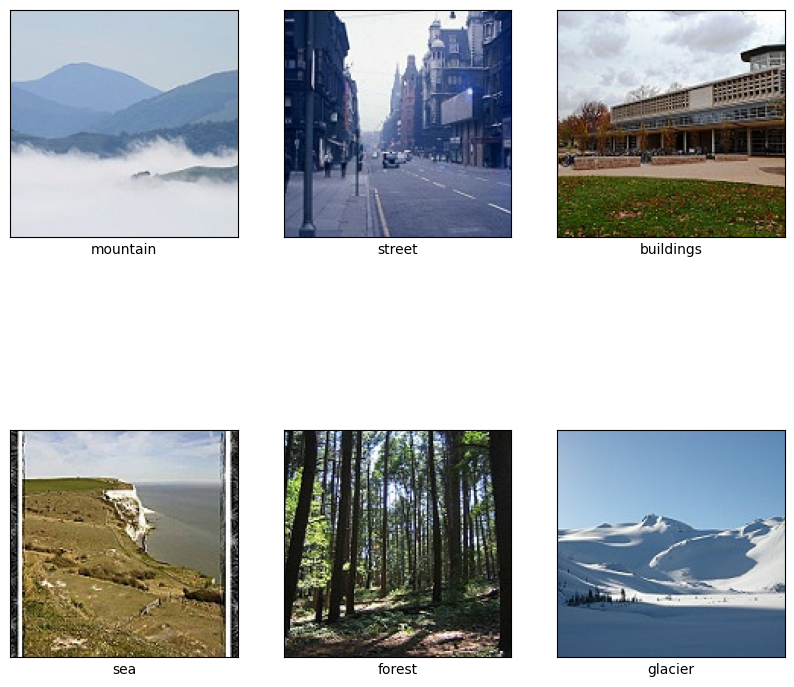

In [38]:
j=0
fig=plt.figure(figsize=(10, 10))
for i in os.listdir(TRAIN_DIR):
        img = mpimg.imread(TRAIN_DIR+"/"+i+"/"+os.listdir(TRAIN_DIR+"/"+i)[0])
        fig.add_subplot(2,3,j+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(img, cmap=plt.cm.binary)
        plt.xlabel(i)
        j += 1
plt.show()

In [39]:
print("TRAINING DATA:")
for i in os.listdir(TRAIN_DIR):
    files = os.listdir(TRAIN_DIR+"/"+i)
    print(f'{i} : {len(files)} files')

print("\n\nTEST DATA:")
for i in os.listdir(TEST_DIR):
    files = os.listdir(TEST_DIR+"/"+i)
    print(f'{i} : {len(files)} files')

TRAINING DATA:
mountain : 2512 files
street : 2382 files
buildings : 2191 files
sea : 2274 files
forest : 2271 files
glacier : 2404 files


TEST DATA:
mountain : 525 files
street : 501 files
buildings : 437 files
sea : 510 files
forest : 474 files
glacier : 553 files


In [40]:
train_generator = TRAIN_DATAGEN.flow_from_directory(
                    TRAIN_DIR,
                    target_size = (150,150),
                    batch_size = BATCH_SIZE,
                    class_mode = 'categorical',
                    subset='training'
                  )

validation_generator = TRAIN_DATAGEN.flow_from_directory(
                    TRAIN_DIR,
                    target_size = (150,150),
                    batch_size = BATCH_SIZE,
                    class_mode = 'categorical',
                    subset='validation'
                  )

test_generator = TEST_DATAGEN.flow_from_directory(
                    TEST_DIR,
                    target_size = (150,150),
                    batch_size = BATCH_SIZE,
                    class_mode = 'categorical'
                  )

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [41]:
conv_base = VGG16(
                    weights = 'imagenet',
                    include_top = False,
                    input_shape = (150,150,3)
                 )

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [42]:
model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(250, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(6, activation='softmax'))

In [43]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Nadam(learning_rate=2e-5),  # Changed from lr to learning_rate
    metrics=['acc']
)

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
561/561 ━━━━━━━━━━━━━━━━━━━━ 9411s 17s/step - acc: 0.6872 - loss: 0.8302 - val_acc: 0.8796 - val_loss: 0.3262
Epoch 2/30
  1/561 ━━━━━━━━━━━━━━━━━━━━ 2:27:12 16s/step - acc: 0.8500 - loss: 0.3608

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


561/561 ━━━━━━━━━━━━━━━━━━━━ 679s 1s/step - acc: 0.8500 - loss: 0.3608 - val_acc: 0.8864 - val_loss: 0.3049
Epoch 3/30
 90/561 ━━━━━━━━━━━━━━━━━━━━ 2:03:15 16s/step - acc: 0.9101 - loss: 0.2594

In [ ]:
def Visualization(history):
  # Plot Loss and Accuracy Curves
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Loss Plot
    ax[0].plot(history.history['loss'], label='Train Loss')
    ax[0].plot(history.history['val_loss'], label='Validation Loss')
    ax[0].set_title('Loss Curve')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()

    # Accuracy Plot
    ax[1].plot(history.history['accuracy'], label='Train Accuracy')
    ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax[1].set_title('Accuracy Curve')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()

    plt.show()